In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("ecommerce_sales_dataset.csv")



Saving ecommerce_sales_dataset.csv to ecommerce_sales_dataset.csv


In [6]:
import pandas as pd

df = pd.read_csv("ecommerce_sales_dataset.csv")
df.head()

,Order ID,Order Date,Customer Name,Product,Category,Quantity,Price,Sales,City,Payment Method
0,10001,2025-05-21,Customer_63,Smartphone,Electronics,1,25000,25000,NaN,Cash
1,10002,2025-02-14,Customer_152,Smartphone,Electronics,5,25000,125000,Trichy,UPI
2,10003,2025-04-22,Customer_60,Laptop,Electronics,1,55000,55000,Salem,UPI
3,10004,2025-11-29,Customer_180,Watch,Accessories,2,3000,6000,Salem,Net Banking
4,10005,2025-10-29,Customer_72,Keyboard,Accessories,4,1200,4800,Chennai,Cash


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order ID        1010 non-null   int64 
 1   Order Date      1010 non-null   object
 2   Customer Name   1010 non-null   object
 3   Product         1010 non-null   object
 4   Category        1010 non-null   object
 5   Quantity        1010 non-null   int64 
 6   Price           1010 non-null   int64 
 7   Sales           1010 non-null   int64 
 8   City            989 non-null    object
 9   Payment Method  995 non-null    object
dtypes: int64(4), object(6)
memory usage: 79.0+ KB


In [8]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer Name,0
Product,0
Category,0
Quantity,0
Price,0
Sales,0
City,21
Payment Method,15


In [9]:
df.duplicated().sum()

np.int64(10)

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Order ID          0
Order Date        0
Customer Name     0
Product           0
Category          0
Quantity          0
Price             0
Sales             0
City              0
Payment Method    0
dtype: int64

Duplicate Rows:
0


In [13]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
print(top_products)

Product
Laptop        11880000
Smartphone     7775000
Watch           918000
Headphones      648000
Shoes           462600
Backpack        403500
Keyboard        344400
Mouse           240000
T-Shirt         188300
Books           153500
Name: Sales, dtype: int64


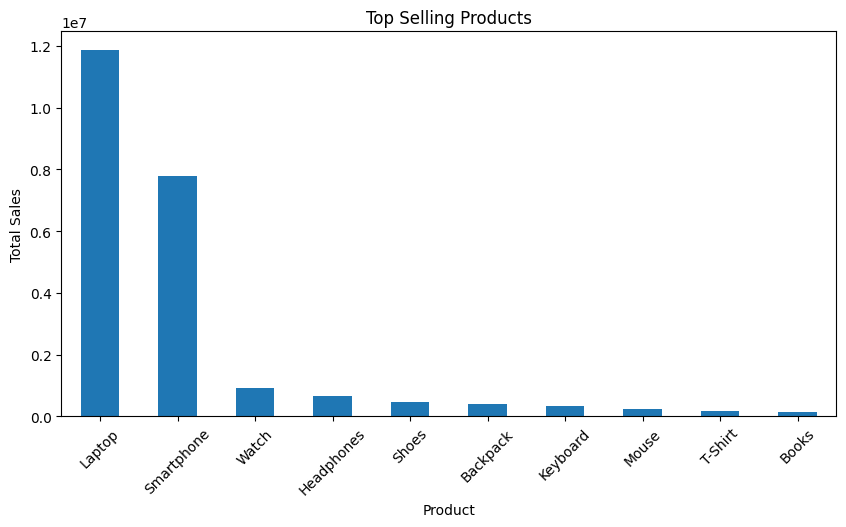

In [14]:
top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month"] = df["Order Date"].dt.month_name()

monthly_sales = df.groupby("Month")["Sales"].sum()

print(monthly_sales)

Month
April        1479200
August       1645700
December     2346700
February     1953000
January      1441500
July         2259500
June         2574300
March        1584000
May          2565900
November     1865200
October      1476800
September    1821500
Name: Sales, dtype: int64


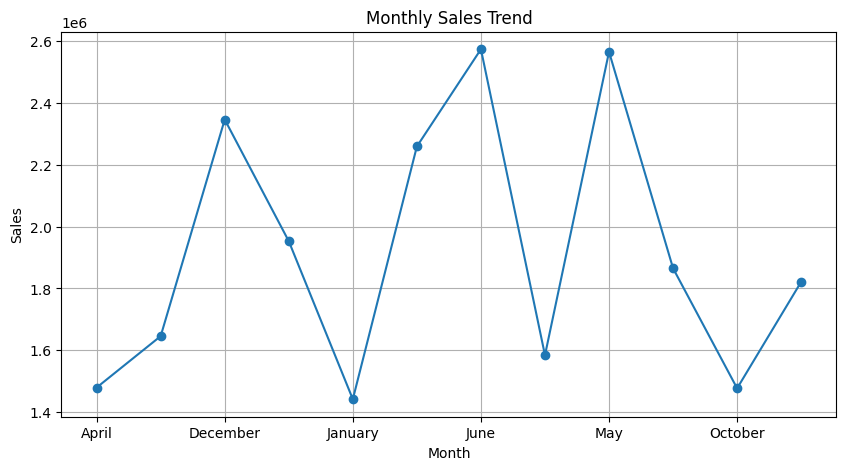

In [16]:
monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

